In [22]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import SM_extractionfunctions

SM_E = SM_extractionfunctions.extract_SMs()

from src.DriftCorrectionFunctions import (
    Drift_Correction_Functions,
    DriftMethod,
    DriftParameters,
    DriftResult,
)

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

/tmp/ipykernel_2853368/1288529626.py:22: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


In [2]:
data_folder = "../../Camera_Calibrations/CS505CU_Calibration/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

In [3]:
objective_T = S_F.getobjectiveefficiency(wavelength)

In [4]:
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])

In [77]:
image_folder = "/scratch/sycamore-asap/2026_Multicolour_Paper/Data/ThorLabs/20250306_MoreDyes/data/atto647n_100pM_PVA_40mW"
metadata_folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/Data/ThorLabs/20250306_MoreDyes/metadata'
image_files = H_F.file_search(image_folder, ".tif", "")
metadata_files = H_F.file_search(metadata_folder, '.json', '638')
x_coord, y_coord, width, height = IO.metadata_reader_Thorlabs(metadata_files[0])

In [78]:
for i, file in enumerate(image_files):
    if i == 0:
        image_stack = IO.read_tiff(file)
    else:
        temp = IO.read_tiff(file)
        image_stack = np.concatenate([image_stack, temp], axis=0)

In [79]:
CPs = np.mean(np.mean(image_stack, axis=-1), axis=-1)

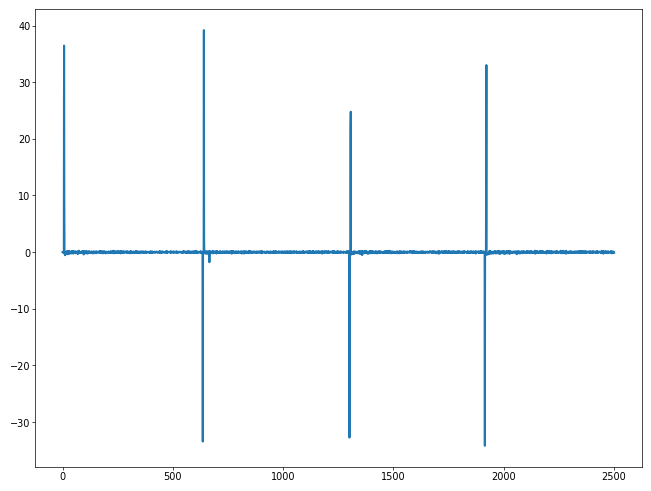

In [80]:
plt.plot(np.diff(CPs)[:])

In [82]:
start = 0
end = 0
for i in np.arange(4):
    new_filename = image_files[0].split('.tif')[0]+'_FOV_{}'.format(str(i).zfill(4))+'.tif'
    start = np.min(np.where(analysis_CPs[end:] > 10))+end
    if i != 3:
        end = np.min(np.where(analysis_CPs[start:] < -10))+end
    else:
        end = -1
    IO.write_tiff(volume=image_stack[start+1:end-1], file_path=new_filename)


In [84]:
image_FOVs = H_F.file_search(image_folder, ".tif", "_FOV_")


In [85]:
data = IO.read_tiff(image_FOVs[0])

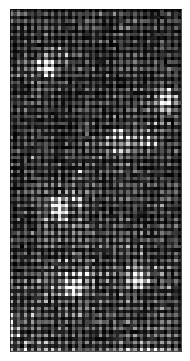

In [168]:
fig, axs = plotter.one_column_plot()

xmin = 400
xmax = 500
ymin = 400
ymax = 450
axs = plotter.image_plot(axs, data[5, xmin:xmax, ymin:ymax], cbar=False, sbar=False)

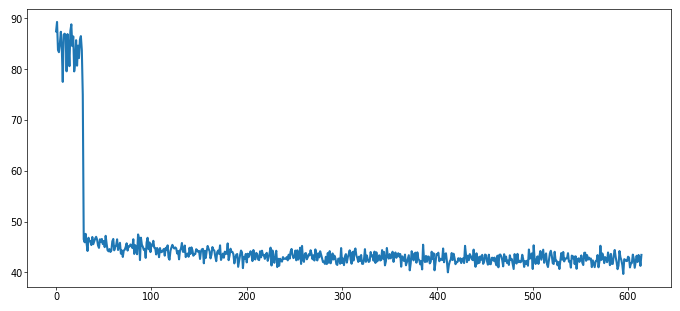

In [116]:
plt.plot(np.mean(np.mean(data[5:, 140:155, 102:117], axis=-1), axis=-1))

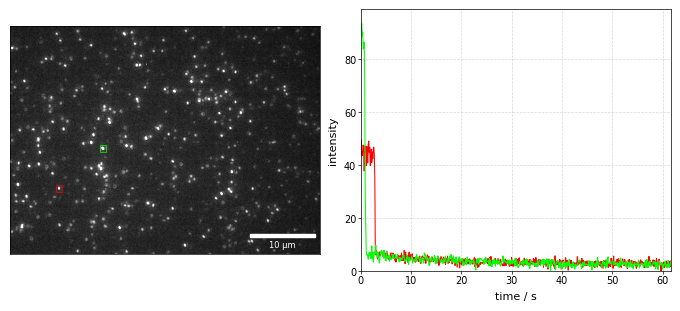

In [166]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=np.ones(2))

frame = 5
xmin = 140
xmax = 155
ymin = 102
ymax = 117
bleach_trace = np.mean(np.mean(data[5:, xmin:xmax, ymin:ymax], axis=-1), axis=-1)
bleach_trace = bleach_trace - np.min(bleach_trace)
axs[0] = plotter.image_plot(axs[0], data[frame, :, :], vmax=np.percentile(data[frame, :, :], 99.5), cbar=False)

t = 0.1
x = np.linspace(0, t*len(bleach_trace) + t, len(bleach_trace))
axs[1] = plotter.line_plot(axs=axs[1], x=x, y=bleach_trace, xaxislabel='time / s', yaxislabel='intensity', color='red')
axs[1].set_xlim([x.min(), x.max()])
axs[1].set_ylim([0, np.max(bleach_trace)*1.05])

import matplotlib.patches as patches

rect = patches.Rectangle(
    (ymin, xmin),
    15,
    15,
    linewidth=0.5,
    edgecolor="red",
    facecolor="none",
)
axs[0].add_patch(rect)

xmin = 230
xmax = 245
ymin = 201
ymax = 216
bleach_trace = np.mean(np.mean(data[5:, xmin:xmax, ymin:ymax], axis=-1), axis=-1)
bleach_trace = bleach_trace - np.min(bleach_trace)
t = 0.1
x = np.linspace(0, t*len(bleach_trace) + t, len(bleach_trace))
axs[1] = plotter.line_plot(axs=axs[1], x=x, y=bleach_trace, xaxislabel='time / s', yaxislabel='intensity', color='lime')
axs[1].set_xlim([x.min(), x.max()])
axs[1].set_ylim([0, np.max(bleach_trace)*1.05])
rect = patches.Rectangle(
    (ymin, xmin),
    15,
    15,
    linewidth=0.5,
    edgecolor="lime",
    facecolor="none",
)
axs[0].add_patch(rect)

xmin = 230
xmax = 245
ymin = 201
ymax = 216
bleach_trace = np.mean(np.mean(data[5:, xmin:xmax, ymin:ymax], axis=-1), axis=-1)
bleach_trace = bleach_trace - np.min(bleach_trace)
t = 0.1
x = np.linspace(0, t*len(bleach_trace) + t, len(bleach_trace))
axs[1] = plotter.line_plot(axs=axs[1], x=x, y=bleach_trace, xaxislabel='time / s', yaxislabel='intensity', color='lime')
axs[1].set_xlim([x.min(), x.max()])
axs[1].set_ylim([0, np.max(bleach_trace)*1.05])
rect = patches.Rectangle(
    (ymin, xmin),
    15,
    15,
    linewidth=0.5,
    edgecolor="lime",
    facecolor="none",
)
axs[0].add_patch(rect)


# Add the patch to the Axes


In [128]:
x = np.linspace(0, t*len(bleach_trace) + t, len(bleach_trace))
x.shape

(615,)

In [ ]:
folders = '/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/Single_Dye_Experiments'
folder_in_folder = os.listdir(folders)

min_cluster_size = 10
chi_val = 2
max_localisation_error = 1.0
min_photons = 100
max_photons = 1e6
max_distance = 0.5

for folder in folder_in_folder:
    print('Analysing {}'.format(folder))
    example_folder = os.path.join(folders, folder)
    localisation_files = H_F.file_search(example_folder, ".h5", "Pos")
    localisation_files = np.sort([x for x in localisation_files if 'database' not in x])
    old_databases = H_F.file_search(example_folder, ".h5", "database")
    old_files = np.sort([x for x in old_databases if 'old' not in x])
    if len(old_files) > 0:
        for file in old_files:
            os.rename(file, file.split('.h5')[0]+'_old.h5')
    single_molecule_database, single_frame_database = SM_E.extract_single_molecules_batch(
        localisation_files,
        clustering_method="HDBSCAN",
        chi_val=chi_val,
        min_cluster_size=min_cluster_size,
        max_localisation_error=max_localisation_error,
        min_photons=min_photons,
        max_photons=max_photons,
    )
    single_molecule_database.to_hdf(os.path.join(example_folder, 'Single_molecule_database.h5'), key="data", append=False, format="table")
    single_frame_database.to_hdf(os.path.join(example_folder, 'Single_frame_database.h5'), key="data", append=False, format="table")